<h3>Use PCA to reduce the dimensionality of an image dataset and apply KNN for classification</h3>

In [1]:
import cupy as cp
from cuml.decomposition import PCA
from cuml.neighbors import KNeighborsClassifier
from cuml.preprocessing import LabelEncoder, StandardScaler
from cuml.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from cuml.preprocessing import StandardScaler
import seaborn as sns
import cudf as df
import matplotlib.pyplot as plt



Here we are going to take the MNIST dataset

In [2]:
train_set = df.read_csv("../datasets/mnist_train.csv")
test_set = df.read_csv("../datasets/mnist_test.csv")

In [3]:
train_set

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train_set.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


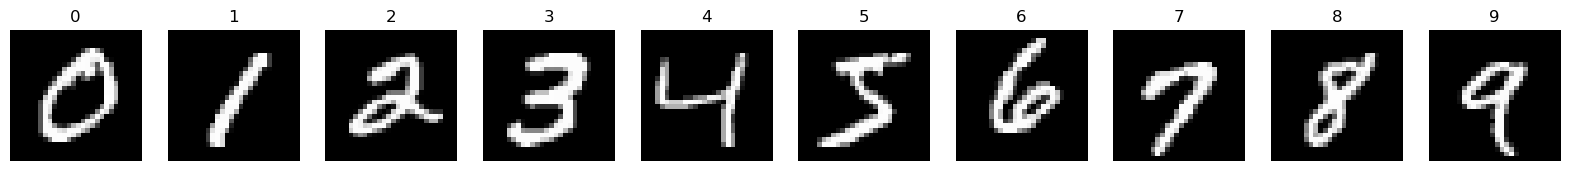

In [5]:
plt.subplots(1, 10, figsize=(20, 17))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    # plt.imshow(train_set[train_set["label"] == i].values[0][1:].reshape(28, 28), cmap="gray")
    image = train_set[train_set["label"] == i].to_numpy()[0][1:].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(i)
plt.show()


In [6]:
for i in range(10):
    print(f"Number of {i} in train set: {train_set[train_set['label'] == i].shape[0]}")
    print(f"Number of {i} in test set: {test_set[test_set['label'] == i].shape[0]}")

Number of 0 in train set: 5923
Number of 0 in test set: 980
Number of 1 in train set: 6742
Number of 1 in test set: 1135
Number of 2 in train set: 5958
Number of 2 in test set: 1032
Number of 3 in train set: 6131
Number of 3 in test set: 1010
Number of 4 in train set: 5842
Number of 4 in test set: 982
Number of 5 in train set: 5421
Number of 5 in test set: 892
Number of 6 in train set: 5918
Number of 6 in test set: 958
Number of 7 in train set: 6265
Number of 7 in test set: 1028
Number of 8 in train set: 5851
Number of 8 in test set: 974
Number of 9 in train set: 5949
Number of 9 in test set: 1009


In [7]:
X_train = train_set.drop("label", axis=1).to_cupy()
y_train = train_set["label"].to_cupy()
X_test = test_set.drop("label", axis=1).to_cupy()
y_test = test_set["label"].to_cupy()

In [10]:
std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)

In [23]:
pca = PCA(n_components=39)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

Training a KNN classifier on the PCA applied dataset

In [24]:
knn_01 = KNeighborsClassifier(n_neighbors = 5)


In [25]:
knn_01.fit(X_train, y_train)

KNeighborsClassifier()

In [26]:
pred_01 = knn_01.predict(X_test)

Accuracy: 0.9581


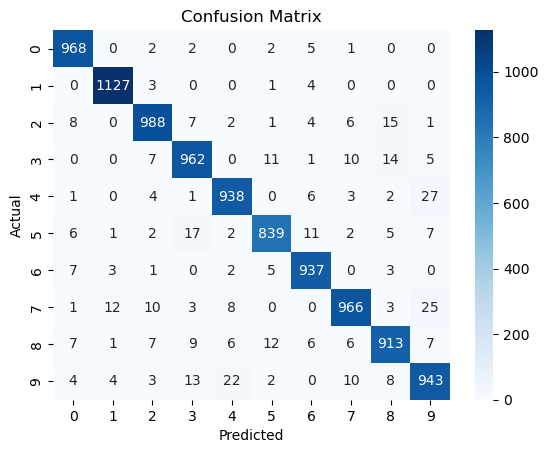

In [27]:
print("Accuracy:", accuracy_score(y_test, pred_01))
conf_matrix = confusion_matrix(y_test, pred_01)

sns.heatmap(conf_matrix.get(), annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [28]:
print(classification_report(y_test.get(), pred_01.get()))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.95      0.95      0.95      1010
           4       0.96      0.96      0.96       982
           5       0.96      0.94      0.95       892
           6       0.96      0.98      0.97       958
           7       0.96      0.94      0.95      1028
           8       0.95      0.94      0.94       974
           9       0.93      0.93      0.93      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



Dataset shape: (400, 4096), Number of classes: 40
PCA-reduced shape: (280, 100)

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       1.00      0.67      0.80         3
           2       1.00      0.67      0.80         3
           3       1.00      0.33      0.50         3
           4       0.40      0.67      0.50         3
           5       0.50      1.00      0.67         3
           6       1.00      1.00      1.00         3
           7       1.00      0.33      0.50         3
           8       1.00      1.00      1.00         3
           9       1.00      0.67      0.80         3
          10       1.00      1.00      1.00         3
          11       1.00      0.67      0.80         3
          12       1.00      0.33      0.50         3
          13       1.00      1.00      1.00         3
          14       0.30      1.00      0.46         3
          15       0.00      0.

/home/hrishikesh/miniconda3/envs/aisemII_new/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hrishikesh/miniconda3/envs/aisemII_new/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hrishikesh/miniconda3/envs/aisemII_new/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

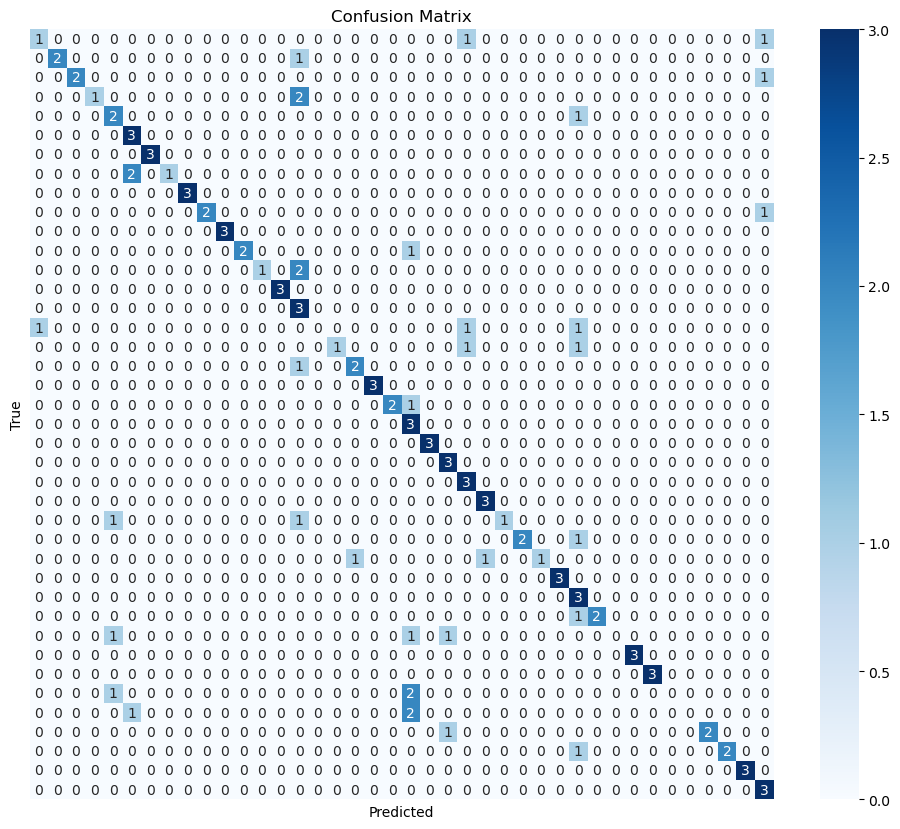

In [9]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load ORL (Olivetti Faces) Dataset
data = fetch_olivetti_faces()
X = data.data  # Flattened 64x64 images = 4096 features
y = data.target  # 40 subjects

print(f"Dataset shape: {X.shape}, Number of classes: {len(np.unique(y))}")

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 3: Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Step 4: Apply PCA
pca = PCA(n_components=100, whiten=True, random_state=42)  # Adjust components as needed
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

print(f"PCA-reduced shape: {X_train_pca.shape}")

# Step 5: Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)

# Step 6: Predict and Evaluate
y_pred = knn.predict(X_test_pca)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

# Step 7: Confusion Matrix Plot
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, annot=True, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()